# Atividade 4 - Compressão, Representação e Descrição

## Aluno: Vitor Fontenele de Oliveira Linhares - 1700778
## [Repositório](https://github.com/Vitorfol/Processamento-de-Imagens/tree/master/4)

### Imports

In [2]:
import numpy as np
import cv2
import matplotlib.pyplot as plt
from pathlib import Path
import pandas as pd

### Setup

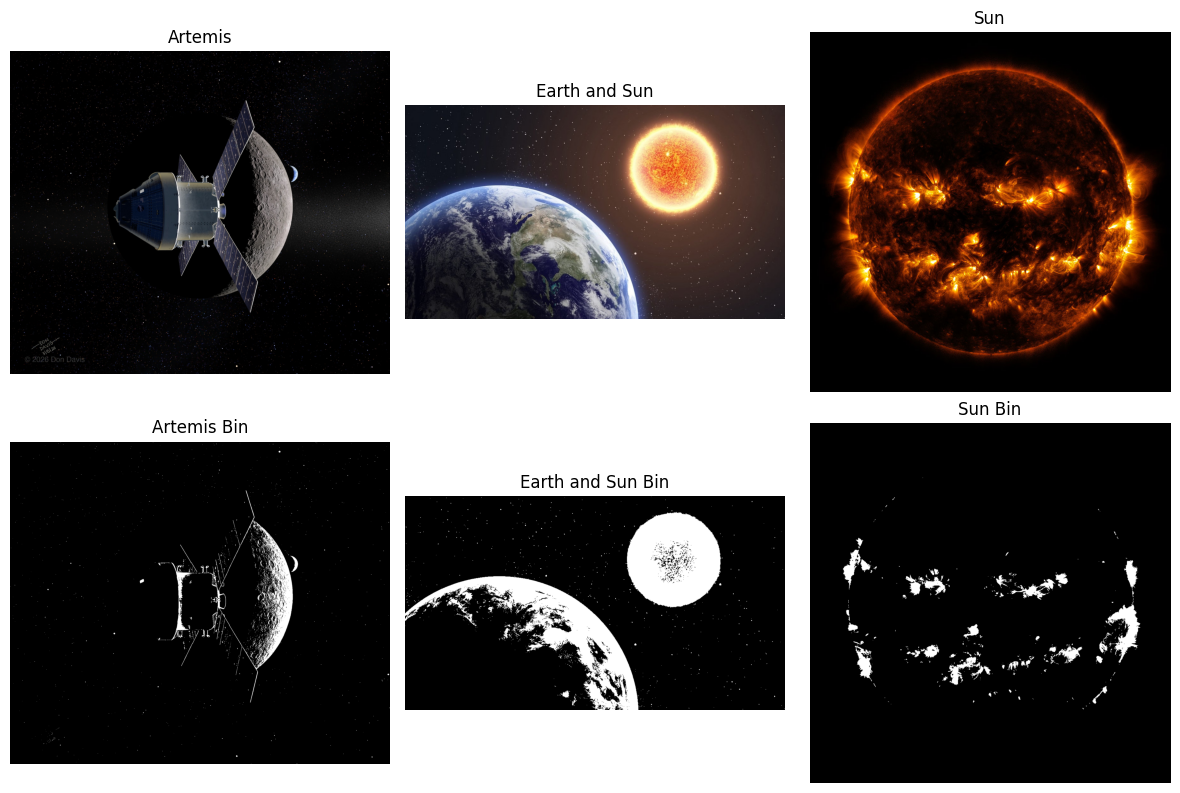

In [15]:
plt.rcParams['image.cmap'] = 'gray'

ARTEMIS_PATH = Path('artemis.jpg')
CRATERS_PATH = Path('craters_moon.jpg')
EARTH_SUN_PATH = Path('earth_and_sun.jpg')
SUN_PATH = Path('sun.jpg')
OUT_DIR = Path('outputs')

def load_image(path):
    path = Path(path)
    if not path.exists():
        raise FileNotFoundError(f'Imagem não encontrada: {path.resolve()}')
    bgr = cv2.imread(str(path), cv2.IMREAD_UNCHANGED)
    if bgr is None:
        raise ValueError(f'Não foi possível ler a imagem: {path.resolve()}')
    if bgr.ndim == 2: 
        return bgr
    return cv2.cvtColor(bgr, cv2.COLOR_BGR2RGB)

def to_gray(img):
    if img.ndim == 2: return img
    return (0.299 * img[:,:,0] + 0.587 * img[:,:,1] + 0.114 * img[:,:,2]).astype(np.float32)

def to_bin(img, threshold=128):
    if img.ndim == 3:
        img = to_gray(img)
    return (img >= threshold).astype(np.uint8) * 255    


def save_image(filename, img, out_dir=OUT_DIR):
    out_dir = Path(out_dir)
    out_dir.mkdir(parents=True, exist_ok=True)
    out_path = out_dir / filename
    arr = np.clip(img, 0, 255).astype(np.uint8)
    if arr.ndim == 3:
        arr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    cv2.imwrite(str(out_path), arr)
    return out_path

def show_grid(images, titles, cols, figsize=None):
    n = len(images)
    rows = (n + cols - 1) // cols
    
    if figsize is None:
        figsize = (cols * 4, rows * 4)
        
    _, axes = plt.subplots(rows, cols, figsize=figsize)
    axes = axes.flatten() if n > 1 else [axes]
    
    for i in range(len(axes)):
        if i < n:
            axes[i].imshow(images[i], vmin=images[i].min(), vmax=images[i].max())
            axes[i].set_title(titles[i])
        axes[i].axis('off')
        
    plt.tight_layout()
    plt.show()
    
def initialize():
    artemis = load_image(ARTEMIS_PATH)
    earth_and_sun = load_image(EARTH_SUN_PATH)
    sun = load_image(SUN_PATH)
    craters_moon = load_image(CRATERS_PATH)

    artemis_bin = to_bin(artemis)
    earth_and_sun_bin = to_bin(earth_and_sun)
    sun_bin = to_bin(sun)
    
    ## Visualmente parece já estar em cinza (imagem do Watershed), mas é melhor prevenir do que remediar :)
    craters_moon_gray = to_gray(craters_moon)

    
    save_image('artemis_bin.jpg', artemis_bin, OUT_DIR)
    save_image('earth_and_sun_bin.jpg', earth_and_sun_bin, OUT_DIR)
    save_image('sun_bin.jpg', sun_bin, OUT_DIR)
    save_image('craters_moon_gray.jpg', craters_moon_gray, OUT_DIR)
    
    show_grid(
        [artemis, earth_and_sun, sun, artemis_bin, earth_and_sun_bin, sun_bin],
        ['Artemis', 'Earth and Sun', 'Sun', 'Artemis Bin', 'Earth and Sun Bin', 'Sun Bin'],
        cols=3
    )

initialize()

### Questão 1

#### Something necessary